In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
netflix=pd.read_csv("C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\data\\netflix_cleaned.csv")

In [3]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [4]:
netflix['date_added']=pd.to_datetime(netflix['date_added'].str.strip())

In [5]:
netflix.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
added_year               int64
dtype: object

In [6]:
netflix['listed_in'].head(20)

0                                         Documentaries
1       International TV Shows, TV Dramas, TV Mysteries
2     Crime TV Shows, International TV Shows, TV Act...
3                                Docuseries, Reality TV
4     International TV Shows, Romantic TV Shows, TV ...
5                    TV Dramas, TV Horror, TV Mysteries
6                              Children & Family Movies
7      Dramas, Independent Movies, International Movies
8                          British TV Shows, Reality TV
9                                      Comedies, Dramas
10    Crime TV Shows, Docuseries, International TV S...
11    Crime TV Shows, International TV Shows, TV Act...
12                         Dramas, International Movies
13                   Children & Family Movies, Comedies
14         British TV Shows, Crime TV Shows, Docuseries
15                               TV Comedies, TV Dramas
16                  Documentaries, International Movies
17    Crime TV Shows, Spanish-Language TV Shows,

In [7]:
netflix[netflix['listed_in'].str.contains(',')]['listed_in'].shape

(6780,)

In [8]:
netflix[~(netflix['listed_in'].str.contains(','))]['listed_in'].shape

(2017,)

In [9]:
netflix[netflix['listed_in'].str.contains(',')]['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 487, dtype: int64

In [10]:
unique_listed=[]
for genres in netflix['listed_in'].tolist():
    if ',' in genres:
        for genre in genres.split(','):
            genre=genre.strip()
            if genre not in unique_listed:
                unique_listed.append(genre)
    else:
        genres=genres.strip()
        if genres not in unique_listed:
            unique_listed.append(genres)
unique_listed

['Documentaries',
 'International TV Shows',
 'TV Dramas',
 'TV Mysteries',
 'Crime TV Shows',
 'TV Action & Adventure',
 'Docuseries',
 'Reality TV',
 'Romantic TV Shows',
 'TV Comedies',
 'TV Horror',
 'Children & Family Movies',
 'Dramas',
 'Independent Movies',
 'International Movies',
 'British TV Shows',
 'Comedies',
 'Spanish-Language TV Shows',
 'Thrillers',
 'Romantic Movies',
 'Music & Musicals',
 'Horror Movies',
 'Sci-Fi & Fantasy',
 'TV Thrillers',
 "Kids' TV",
 'Action & Adventure',
 'TV Sci-Fi & Fantasy',
 'Classic Movies',
 'Anime Features',
 'Sports Movies',
 'Anime Series',
 'Korean TV Shows',
 'Science & Nature TV',
 'Teen TV Shows',
 'Cult Movies',
 'TV Shows',
 'Faith & Spirituality',
 'LGBTQ Movies',
 'Stand-Up Comedy',
 'Movies',
 'Stand-Up Comedy & Talk Shows',
 'Classic & Cult TV']

In [11]:
categories_to_drop = [
    'International TV Shows',
    'British TV Shows',
    'Spanish-Language TV Shows',
    'International Movies',
    'Korean TV Shows',
    'Children & Family Movies',
    'Crime TV Shows',
    'Independent Movies',
    "Kids' TV",
    'Teen TV Shows',
    'TV Shows',
    'Movies'
]
netflix=netflix.assign(listed_in=lambda x:x['listed_in'].apply(
    lambda value:','.join(
        category.strip() for category in value.split(',')
        if category.strip() not in categories_to_drop
    ) or np.nan
) )

In [12]:
unique_listed=[]
for genres in netflix['listed_in'].tolist():
    if pd.notna(genres):
        if ',' in genres:
            for genre in genres.split(','):
                genre=genre.strip()
                if genre not in unique_listed:
                    unique_listed.append(genre)
        else:
            genres=genres.strip()
            if genres not in unique_listed:
                unique_listed.append(genres)
unique_listed

['Documentaries',
 'TV Dramas',
 'TV Mysteries',
 'TV Action & Adventure',
 'Docuseries',
 'Reality TV',
 'Romantic TV Shows',
 'TV Comedies',
 'TV Horror',
 'Dramas',
 'Comedies',
 'Thrillers',
 'Romantic Movies',
 'Music & Musicals',
 'Horror Movies',
 'Sci-Fi & Fantasy',
 'TV Thrillers',
 'Action & Adventure',
 'TV Sci-Fi & Fantasy',
 'Classic Movies',
 'Anime Features',
 'Sports Movies',
 'Anime Series',
 'Science & Nature TV',
 'Cult Movies',
 'Faith & Spirituality',
 'LGBTQ Movies',
 'Stand-Up Comedy',
 'Stand-Up Comedy & Talk Shows',
 'Classic & Cult TV']

In [13]:
netflix['listed_in'].info()

<class 'pandas.Series'>
RangeIndex: 8797 entries, 0 to 8796
Series name: listed_in
Non-Null Count  Dtype
--------------  -----
8130 non-null   str  
dtypes: str(1)
memory usage: 68.9 KB


In [14]:
netflix=netflix[~(netflix['listed_in'].isna())]
netflix.shape

(8130, 13)

In [15]:
netflix['listed_in']=netflix['listed_in'].str.split(',')
netflix=netflix.explode('listed_in',ignore_index=True)
netflix['listed_in'].value_counts()

listed_in
Dramas                          2427
Comedies                        1674
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Romantic Movies                  616
Thrillers                        577
TV Comedies                      574
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     175
TV Action & Adventure            167
Classic Movies                   116
LGBTQ Movies                     102
TV Mysteries                      98
Science & Nature TV               92
TV Sci-Fi & Fantasy               83
TV Horror                         75
Anime Features                    71
Cult Movies                       71
Faith & Spirituality        

In [16]:
netflix.shape

(12168, 13)

In [17]:
netflix[netflix['listed_in'].str.contains(',')]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year


In [18]:
genre_by_year=pd.get_dummies(netflix,columns=['listed_in'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
genre_by_year

,listed_in_Action & Adventure,listed_in_Anime Features,listed_in_Anime Series,listed_in_Classic & Cult TV,listed_in_Classic Movies,listed_in_Comedies,listed_in_Cult Movies,listed_in_Documentaries,listed_in_Docuseries,listed_in_Dramas,...,listed_in_Stand-Up Comedy,listed_in_Stand-Up Comedy & Talk Shows,listed_in_TV Action & Adventure,listed_in_TV Comedies,listed_in_TV Dramas,listed_in_TV Horror,listed_in_TV Mysteries,listed_in_TV Sci-Fi & Fantasy,listed_in_TV Thrillers,listed_in_Thrillers
added_year,,,,,,,,,,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
2009,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2010,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011,0,0,0,0,0,0,0,0,0,13,...,0,0,0,0,0,0,0,0,0,1
2012,0,0,0,0,0,2,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2013,0,0,0,0,0,1,0,1,1,0,...,4,1,0,0,4,0,1,1,1,0
2014,1,0,0,1,0,2,0,8,0,0,...,4,0,0,3,3,0,0,0,1,0
2015,2,0,0,1,0,12,0,13,5,12,...,13,0,2,8,8,2,2,2,1,2
2016,18,4,14,1,2,48,1,68,28,65,...,39,1,8,40,43,5,4,3,5,14


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, '2008'),
  Text(1, 0, '2009'),
  Text(2, 0, '2010'),
  Text(3, 0, '2011'),
  Text(4, 0, '2012'),
  Text(5, 0, '2013'),
  Text(6, 0, '2014'),
  Text(7, 0, '2015'),
  Text(8, 0, '2016'),
  Text(9, 0, '2017'),
  Text(10, 0, '2018'),
  Text(11, 0, '2019'),
  Text(12, 0, '2020'),
  Text(13, 0, '2021')])

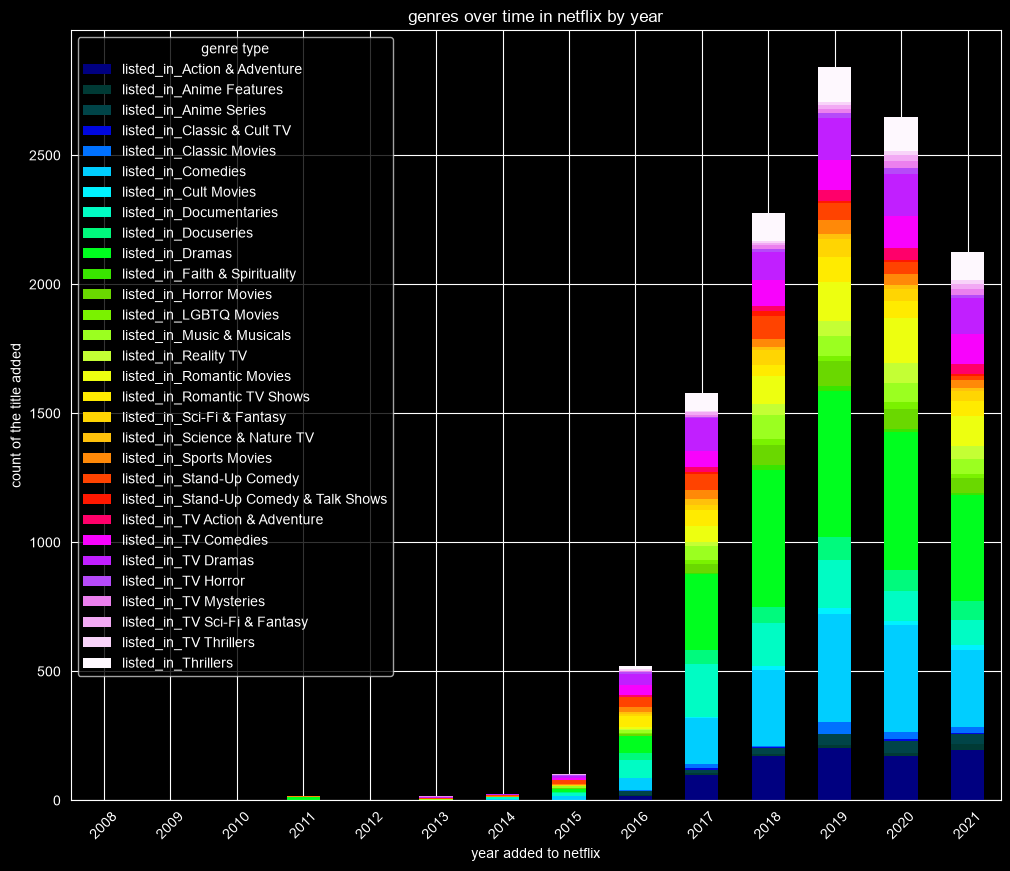

In [19]:
genre_by_year.plot(kind='bar',stacked=True,figsize=(12,10),edgecolor='none',colormap='gist_ncar')
plt.title('genres over time in netflix by year')
plt.xlabel('year added to netflix')
plt.ylabel('count of the title added')
plt.legend(title='genre type')
plt.xticks(rotation=45)

In [20]:
genre_proportion=genre_by_year.div(genre_by_year.sum(axis=1),axis=0)*100
genre_proportion

,listed_in_Action & Adventure,listed_in_Anime Features,listed_in_Anime Series,listed_in_Classic & Cult TV,listed_in_Classic Movies,listed_in_Comedies,listed_in_Cult Movies,listed_in_Documentaries,listed_in_Docuseries,listed_in_Dramas,...,listed_in_Stand-Up Comedy,listed_in_Stand-Up Comedy & Talk Shows,listed_in_TV Action & Adventure,listed_in_TV Comedies,listed_in_TV Dramas,listed_in_TV Horror,listed_in_TV Mysteries,listed_in_TV Sci-Fi & Fantasy,listed_in_TV Thrillers,listed_in_Thrillers
added_year,,,,,,,,,,,,,,,,,,,,,
2008,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.333333,...,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,33.333333
2009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.470588,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.882353
2012,0.000000,0.000000,0.000000,0.000000,0.000000,66.666667,0.000000,33.333333,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013,0.000000,0.000000,0.000000,0.000000,0.000000,5.882353,0.000000,5.882353,5.882353,0.000000,...,23.529412,5.882353,0.000000,0.000000,23.529412,0.000000,5.882353,5.882353,5.882353,0.000000
2014,3.846154,0.000000,0.000000,3.846154,0.000000,7.692308,0.000000,30.769231,0.000000,0.000000,...,15.384615,0.000000,0.000000,11.538462,11.538462,0.000000,0.000000,0.000000,3.846154,0.000000
2015,1.923077,0.000000,0.000000,0.961538,0.000000,11.538462,0.000000,12.500000,4.807692,11.538462,...,12.500000,0.000000,1.923077,7.692308,7.692308,1.923077,1.923077,1.923077,0.961538,1.923077
2016,3.448276,0.766284,2.681992,0.191571,0.383142,9.195402,0.191571,13.026820,5.363985,12.452107,...,7.471264,0.191571,1.532567,7.662835,8.237548,0.957854,0.766284,0.574713,0.957854,2.681992


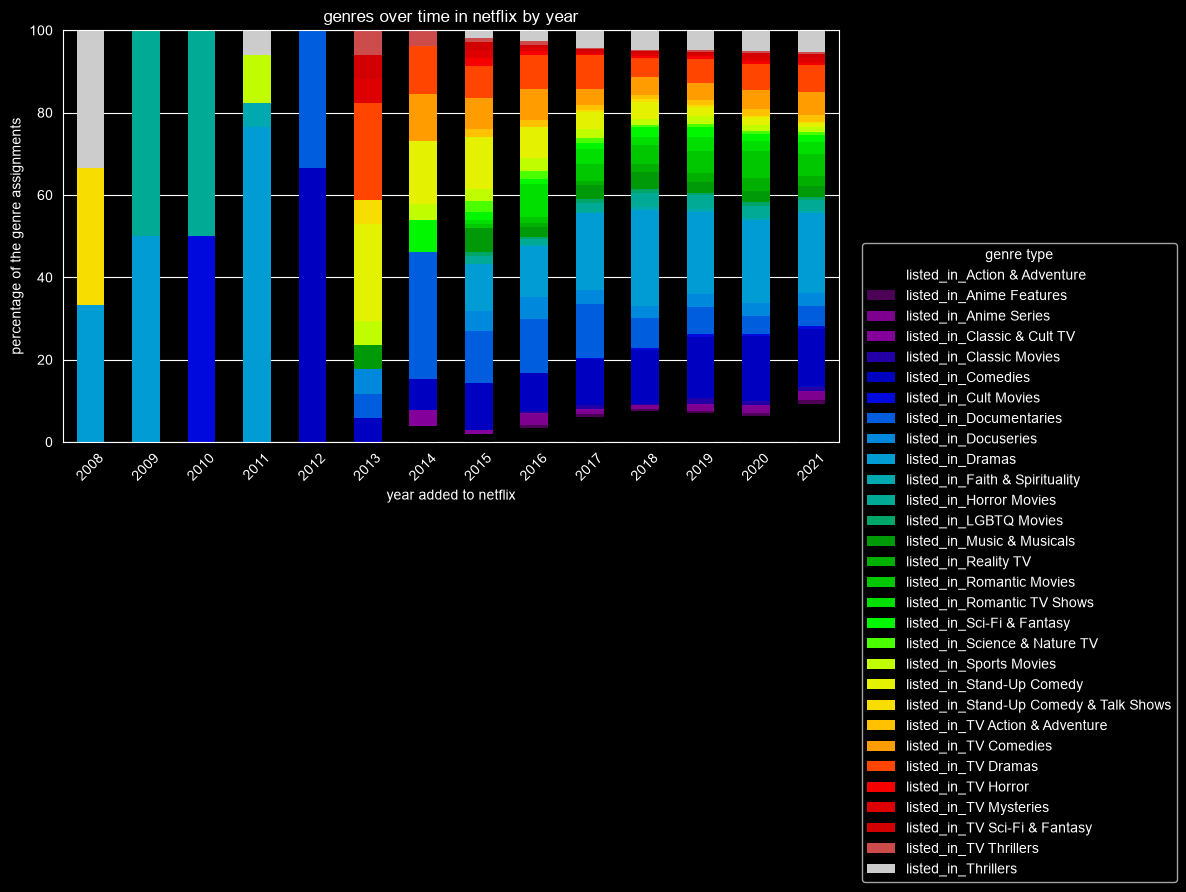

In [21]:
genre_proportion.plot(kind='bar',stacked=True,figsize=(12,8),edgecolor='none',colormap='nipy_spectral')
plt.title('genres over time in netflix by year')
plt.xlabel('year added to netflix')
plt.ylabel('percentage of the genre assignments')
plt.legend(title='genre type',loc='upper left',bbox_to_anchor=(1.02,0.5))
plt.xticks(rotation=45)
plt.tight_layout()

In [22]:
genre_by_year.sum(axis=0)

listed_in_Action & Adventure               859
listed_in_Anime Features                    71
listed_in_Anime Series                     175
listed_in_Classic & Cult TV                 26
listed_in_Classic Movies                   116
listed_in_Comedies                        1674
listed_in_Cult Movies                       71
listed_in_Documentaries                    869
listed_in_Docuseries                       394
listed_in_Dramas                          2427
listed_in_Faith & Spirituality              65
listed_in_Horror Movies                    357
listed_in_LGBTQ Movies                     102
listed_in_Music & Musicals                 375
listed_in_Reality TV                       255
listed_in_Romantic Movies                  616
listed_in_Romantic TV Shows                370
listed_in_Sci-Fi & Fantasy                 243
listed_in_Science & Nature TV               92
listed_in_Sports Movies                    219
listed_in_Stand-Up Comedy                  343
listed_in_Sta

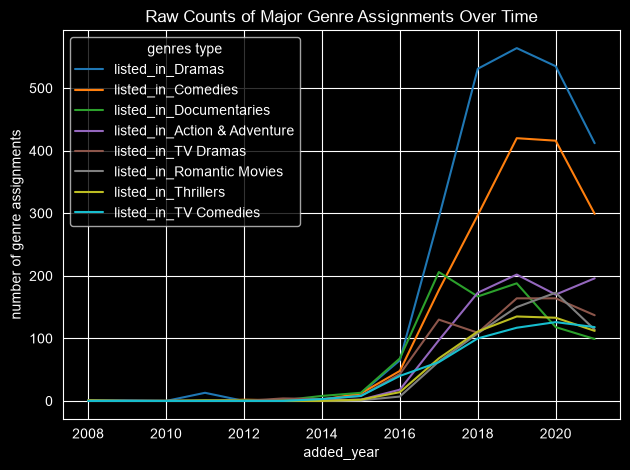

In [23]:
genre_by_year.plot(
    y=[
        'listed_in_Dramas',
        'listed_in_Comedies',
        'listed_in_Documentaries',
        'listed_in_Action & Adventure',
        'listed_in_TV Dramas',
        'listed_in_Romantic Movies',
        'listed_in_Thrillers',
        'listed_in_TV Comedies'
    ],colormap='tab10'
)
plt.title('Raw Counts of Major Genre Assignments Over Time')
plt.ylabel('number of genre assignments')
plt.legend(title='genres type')
plt.tight_layout()

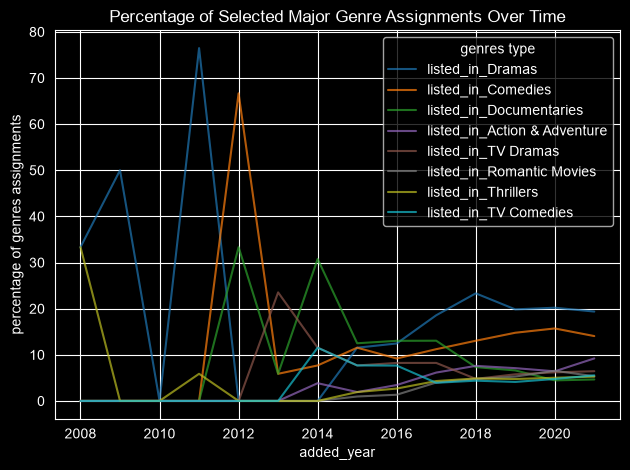

In [24]:
genre_proportion.plot(
    y=[
        'listed_in_Dramas',
        'listed_in_Comedies',
        'listed_in_Documentaries',
        'listed_in_Action & Adventure',
        'listed_in_TV Dramas',
        'listed_in_Romantic Movies',
        'listed_in_Thrillers',
        'listed_in_TV Comedies'
    ],colormap='tab10',alpha=0.7
)
plt.title('Percentage of Selected Major Genre Assignments Over Time')
plt.ylabel('percentage of genres assignments')
plt.legend(title='genres type')
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\Selected_Major_Genre.png',dpi=300,bbox_inches='tight')